## 1 | Datensatz kurz vorgestellt

Quelle: Fake News Detection Datasets (Kaggle-Link oben).

Dateien: Fake.csv (≈ 23 481 Zeilen) und True.csv (≈ 21 417 Zeilen) – jeweils mit den Spalten title, text, subject, date Kaggle
Label: Wir fügen eine Binär-Spalte label hinzu (0 = fake, 1 = true) und legen beide Dateien zu einem Data-Frame df zusammen.

In [11]:
import sys; sys.path.insert(0, '..')
import yaml
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

from src.data_loading import load_fake_news_data, set_seeds
from src.plotting import setup_plot_style, plot_comparison_bars, plot_wordclouds
from src.text_features import get_top_n_words, build_count_vectorizer
from src.evaluation import perform_multiple_ttests_with_correction

cfg = yaml.safe_load(open(Path('../configs/default.yaml')))
set_seeds(cfg['random_seed'])
setup_plot_style(cfg)

## 2 | Exploratory Data Analysis (EDA)

In [4]:
df = load_fake_news_data(cfg)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


In [6]:
df.label.value_counts(normalize=True)

label
0    0.522985
1    0.477015
Name: proportion, dtype: float64

<Axes: xlabel='subject'>

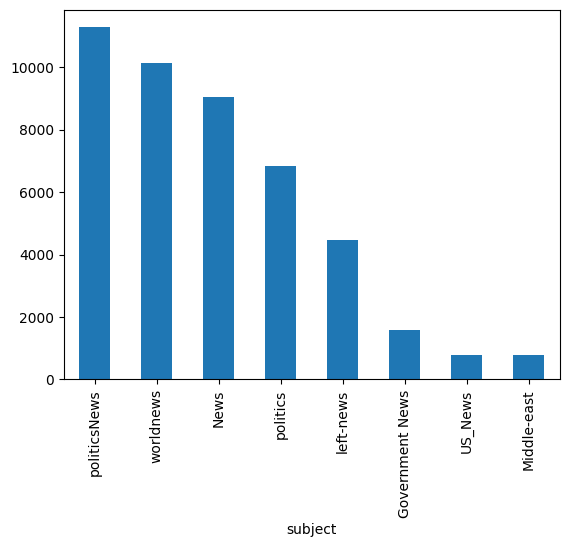

In [7]:
df.subject.value_counts().plot.bar()

<Axes: xlabel='num_words', ylabel='Count'>

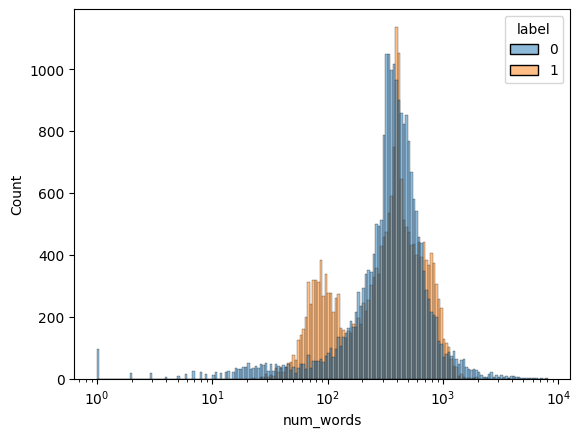

In [8]:
df["num_words"] = df.text.str.split().str.len()
sns.histplot(data=df, x="num_words", hue="label", log_scale=True)

<Axes: xlabel='date'>

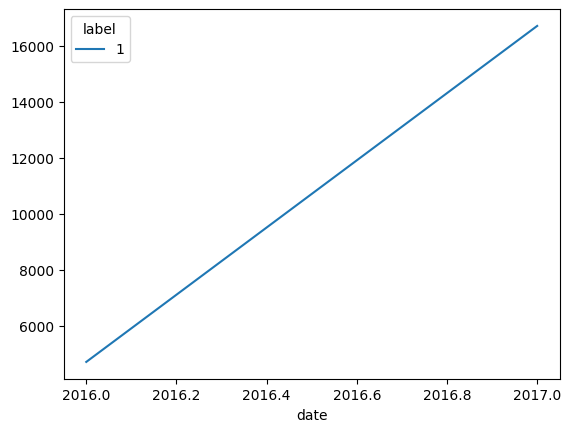

In [9]:
df.date = pd.to_datetime(df.date, errors="coerce")
df.groupby([df.date.dt.year,"label"]).size().unstack().plot()

In [10]:
X, feature_names, cv = build_count_vectorizer(
    df['text'],
    ngram_range=cfg['fake_news']['ngram_range'],
    stop_words='english'
)

In [12]:
n = cfg['fake_news']['top_n_words']
top_fake = get_top_n_words(X, feature_names, df['label'], 0, n)
top_true = get_top_n_words(X, feature_names, df['label'], 1, n)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))
sns.barplot(x='count', y='term', data=top_fake, ax=ax1, color='red')
ax1.set_title(f'Top {n} N-Grams in Fake News')
ax1.set_xlabel('Anzahl')
ax1.set_ylabel('Woerter und Phrasen')
sns.barplot(x='count', y='term', data=top_true, ax=ax2, color='green')
ax2.set_title(f'Top {n} N-Grams in True News')
ax2.set_xlabel('Anzahl')
ax2.set_ylabel('')
plt.tight_layout()
plt.show()

# Wordclouds
fake_text = ' '.join(df[df['label'] == 0]['text'])
true_text = ' '.join(df[df['label'] == 1]['text'])
plot_wordclouds(
    [fake_text, true_text],
    ['Reds', 'Greens'],
    ['Fake News (Label = 0)', 'True News (Label = 1)']
)

In [13]:
# Gruppiertes Balkendiagramm nach Subject und Label
ct = pd.crosstab(df['subject'], df['label'])
ct.columns = ['Fake News (0)', 'True News (1)']
plot_comparison_bars(ct, 'Verteilung der Nachrichten nach Thema und Label', 'Thema (Subject)', 'Anzahl')

# Prozentuale Verteilung
ct_pct = pd.crosstab(df['subject'], df['label'], normalize='index') * 100
ct_pct.columns = ['Fake News (0)', 'True News (1)']
plot_comparison_bars(ct_pct, 'Prozentuale Verteilung von Fake/True News nach Thema', 'Thema (Subject)', 'Prozent (%)', stacked=True)

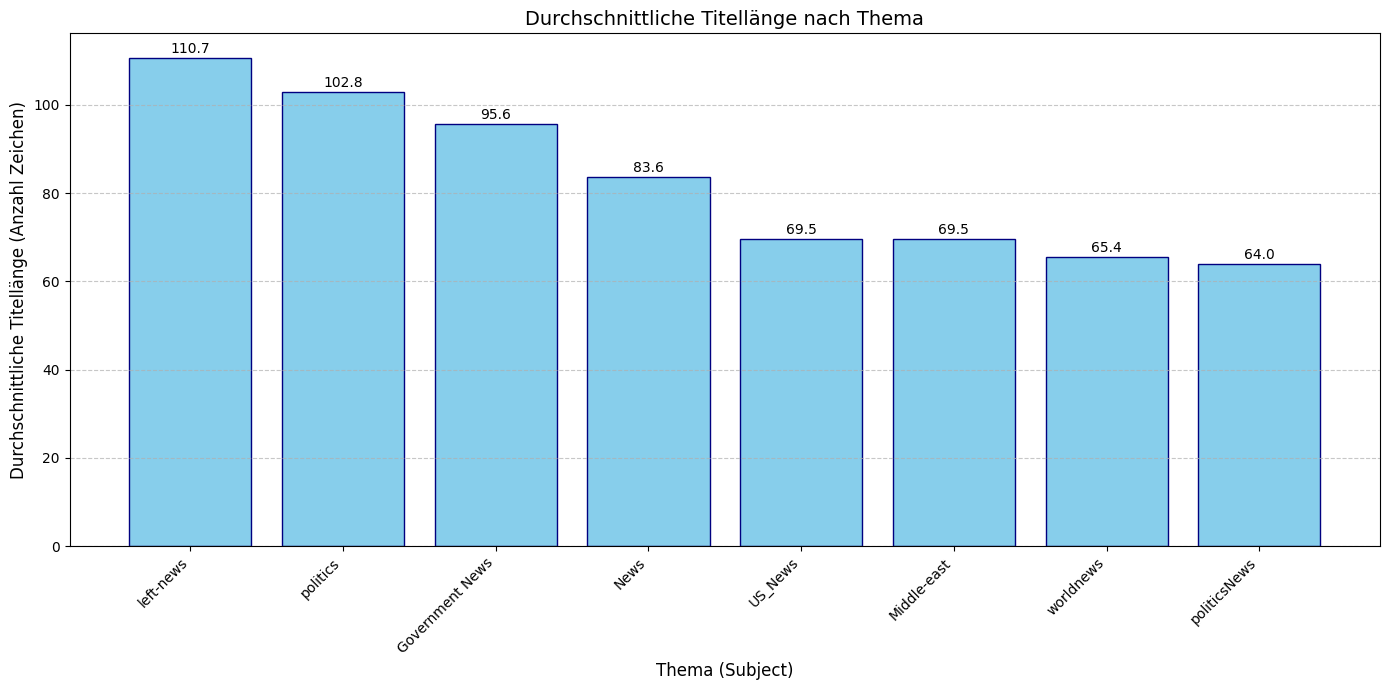

<Figure size 1400x700 with 0 Axes>

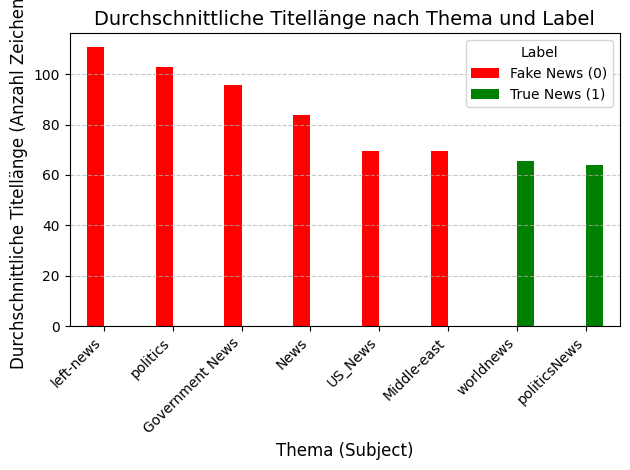

In [15]:
# Titellänge berechnen und als neue Spalte hinzufügen
df['title_length'] = df['title'].str.len()

# Variante 1: Durchschnittliche Titellänge pro Thema
plt.figure(figsize=(14, 7))

# Gruppieren nach Subject und Durchschnitt berechnen
title_length_by_subject = df.groupby('subject')['title_length'].mean().sort_values(ascending=False)

# Balkendiagramm erstellen
bars = plt.bar(title_length_by_subject.index, title_length_by_subject.values, color='skyblue', edgecolor='navy')

# Werte über den Balken anzeigen
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{height:.1f}', ha='center', va='bottom', fontsize=10)

# Diagramm-Titel und Beschriftungen
plt.title('Durchschnittliche Titellänge nach Thema', fontsize=14)
plt.xlabel('Thema (Subject)', fontsize=12)
plt.ylabel('Durchschnittliche Titellänge (Anzahl Zeichen)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Variante 2: Titellänge nach Thema und Label (Fake vs. True)
plt.figure(figsize=(14, 7))

# Durchschnittliche Titellänge nach Subject und Label
title_length_by_subject_label = df.groupby(['subject', 'label'])['title_length'].mean().unstack()
title_length_by_subject_label.columns = ['Fake News (0)', 'True News (1)']

# Sortieren nach Gesamtdurchschnitt
title_length_by_subject = df.groupby('subject')['title_length'].mean().sort_values(ascending=False)
sorted_index = title_length_by_subject.index

# Gruppiertes Balkendiagramm erstellen
title_length_by_subject_label.loc[sorted_index].plot(kind='bar', color=['red', 'green'])

# Diagramm-Titel und Beschriftungen
plt.title('Durchschnittliche Titellänge nach Thema und Label', fontsize=14)
plt.xlabel('Thema (Subject)', fontsize=12)
plt.ylabel('Durchschnittliche Titellänge (Anzahl Zeichen)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Label')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [16]:
from scipy import stats

df['title_length'] = df['title'].str.len()

# T-Tests mit FDR-Korrektur
results = perform_multiple_ttests_with_correction(df, 'title_length', 'subject', correction_method='fdr_bh')
print(f"Anzahl der signifikanten Unterschiede: {results['Signifikant'].sum()} von {len(results)}")
display(results)

# Heatmap der p-Werte
plt.figure(figsize=(14, 12))
subjects = sorted(df['subject'].unique())
n_subjects = len(subjects)
p_matrix = np.ones((n_subjects, n_subjects))
for idx, row in results.iterrows():
    s1, s2 = row['Vergleich'].split(' vs ')
    i, j = subjects.index(s1), subjects.index(s2)
    p_matrix[i, j] = p_matrix[j, i] = row['p-Wert (korrigiert)']
mask = np.triu(np.ones_like(p_matrix, dtype=bool))
sns.heatmap(p_matrix, mask=mask, annot=True, fmt='.3f', cmap='YlGnBu_r',
            xticklabels=subjects, yticklabels=subjects, vmax=0.05, vmin=0,
            square=True, cbar_kws={'label': 'Korrigierter p-Wert'})
plt.title('Signifikanzmatrix fuer Unterschiede in der Titellaenge zwischen Themen', fontsize=14)
plt.tight_layout()
plt.show()

# Konfidenzintervalle
plt.figure(figsize=(14, 8))
subject_stats = []
for subject in subjects:
    data = df[df['subject'] == subject]['title_length']
    mean = data.mean()
    ci = stats.t.interval(0.95, len(data)-1, loc=mean, scale=stats.sem(data))
    subject_stats.append({'subject': subject, 'mean': mean, 'ci_low': ci[0], 'ci_high': ci[1], 'count': len(data)})
stats_df = pd.DataFrame(subject_stats).sort_values('mean', ascending=False)
plt.errorbar(x=range(len(stats_df)), y=stats_df['mean'],
             yerr=[(stats_df['mean']-stats_df['ci_low']), (stats_df['ci_high']-stats_df['mean'])],
             fmt='o', capsize=5, capthick=2, elinewidth=2, markersize=8, color='blue')
bars = plt.bar(range(len(stats_df)), stats_df['mean'], alpha=0.5, color='skyblue')
plt.xticks(range(len(stats_df)), stats_df['subject'], rotation=45, ha='right')
plt.title('Durchschnittliche Titellaenge nach Thema mit 95% Konfidenzintervallen', fontsize=14)
plt.ylabel('Durchschnittliche Titellaenge (Zeichen)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, bar in enumerate(bars):
    plt.text(i, bar.get_height() + 2, f"n={stats_df.iloc[i]['count']}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()